# Tugas Lab 1 — kNN untuk Klasifikasi Suara (voice.csv)

## 1. Buatlah model klasifikasi dengan menggunakan kNN untuk mengklasifikasikan jenis suara male dan female pada dataset voice.csv.

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv('voice.csv')
print(df.shape, '| missing:', df.isna().sum().sum())
print(df['label'].value_counts())

X = df.drop(columns='label')
y = (df['label'] == 'male').astype(int)   # male=1, female=0

# Split dulu (stratify), lalu semua pemilihan fitur & k HANYA memakai data train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
cv = StratifiedKFold(5, shuffle=True, random_state=42)

# Scaler ada di dalam pipeline -> di-fit ulang per fold CV, tidak ada data leakage
def cv_acc(cols, k=5):
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    return cross_val_score(pipe, X_train[cols], y_train, cv=cv).mean()

# Baseline: semua 20 fitur
print('Baseline (20 fitur, k=5) CV acc:', round(cv_acc(list(X.columns)), 4))

(3168, 21) | missing: 0
label
male      1584
female    1584
Name: count, dtype: int64
Baseline (20 fitur, k=5) CV acc: 0.968


## 2. Lakukan percobaan untuk mengetahui fitur-fitur yang paling optimal untuk digunakan. Fitur apa saja yang Anda gunakan untuk mendapatkan hasil terbaik?

In [ ]:
# (a) Akurasi tiap fitur secara tunggal
single = pd.Series({c: cv_acc([c]) for c in X.columns}).sort_values(ascending=False)
print(single.round(4).head(8))

# (b) Korelasi antar fitur (cek redundansi)
corr = X.corr().abs()
pairs = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack().sort_values(ascending=False)
print(pairs.head(6).round(3))

meanfun    0.9441
IQR        0.8967
Q25        0.8746
sd         0.7871
sp.ent     0.7072
sfm        0.6712
mode       0.6685
skew       0.6206
dtype: float64
meanfreq  centroid    1.000
maxdom    dfrange     1.000
skew      kurt        0.977
meanfreq  median      0.925
median    centroid    0.925
meanfreq  Q25         0.911
dtype: float64


In [ ]:
# (c) Forward selection: tambah satu fitur yang paling menaikkan CV accuracy, ulangi sampai semua fitur terpakai
selected, remaining, hist = [], list(X.columns), []
while remaining:
    scores = {c: cv_acc(selected + [c]) for c in remaining}
    best = max(scores, key=scores.get)
    selected.append(best); remaining.remove(best)
    hist.append((len(selected), best, scores[best]))

hist_df = pd.DataFrame(hist, columns=['n_fitur', 'fitur_ditambah', 'cv_acc'])
print(hist_df.round(4).to_string(index=False))

plt.figure(figsize=(8,4))
plt.plot(hist_df.n_fitur, hist_df.cv_acc, marker='o')
plt.axhline(cv_acc(list(X.columns)), ls='--', c='gray', label='semua 20 fitur')
plt.xticks(range(1, 21)); plt.xlabel('Jumlah fitur'); plt.ylabel('CV accuracy (k=5)')
plt.title('Forward Selection'); plt.legend(); plt.grid(alpha=.3); plt.show()

n_best = int(hist_df.loc[hist_df.cv_acc.idxmax(), 'n_fitur'])
features = selected[:n_best]
print('Fitur terpilih:', features)

##3. Berdasarkan fitur yang telah Anda pilih pada soal nomor 2, berapa nilai yang terbaik? Lampirkan grafika analisis dan alasan Anda.

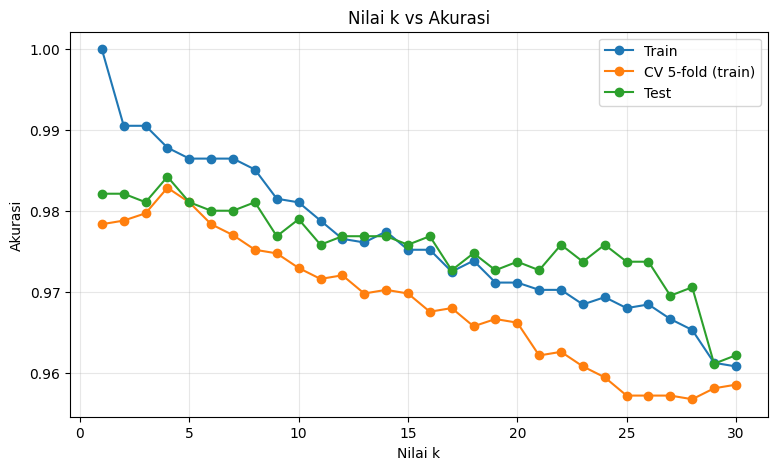

k terbaik overall (CV): 4 | CV acc = 0.9829
k ganjil terbaik (CV): 5 | CV acc = 0.9811


In [41]:
ks = range(1, 31)
tr_acc, cv_scores, te_acc = [], [], []
for k in ks:
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    cv_scores.append(cross_val_score(pipe, X_train[features], y_train, cv=cv).mean())
    pipe.fit(X_train[features], y_train)
    tr_acc.append(pipe.score(X_train[features], y_train))
    te_acc.append(pipe.score(X_test[features], y_test))

plt.figure(figsize=(9,5))
plt.plot(ks, tr_acc, marker='o', label='Train')
plt.plot(ks, cv_scores, marker='o', label='CV 5-fold (train)')
plt.plot(ks, te_acc, marker='o', label='Test')
plt.xlabel('Nilai k'); plt.ylabel('Akurasi'); plt.title('Nilai k vs Akurasi'); plt.legend(); plt.grid(alpha=.3)
plt.show()

# k genap bisa menghasilkan vote seri -> pilih k ganjil dengan CV tertinggi (sesuai best practice modul)
odd = [k for k in ks if k % 2 == 1]
best_k = max(odd, key=lambda k: cv_scores[k-1])
print('k terbaik overall (CV):', list(ks)[int(np.argmax(cv_scores))], '| CV acc =', round(max(cv_scores), 4))
print('k ganjil terbaik (CV):', best_k, '| CV acc =', round(cv_scores[best_k-1], 4))

In [42]:
# Evaluasi akhir (test set dipakai sekali, setelah fitur & k ditentukan)
final = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k)).fit(X_train[features], y_train)
y_pred = final.predict(X_test[features])
print('Akurasi test:', round(accuracy_score(y_test, y_pred), 4))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['female', 'male']))

Akurasi test: 0.9811
[[466  10]
 [  8 467]]
              precision    recall  f1-score   support

      female       0.98      0.98      0.98       476
        male       0.98      0.98      0.98       475

    accuracy                           0.98       951
   macro avg       0.98      0.98      0.98       951
weighted avg       0.98      0.98      0.98       951



analisa : k dipilih berdasarkan CV pada data train (bukan test) agar tidak bias. Pada k=1 akurasi train 100% tetapi CV (97.8%) lebih rendah, ciri overfitting (model menghafal data). Saat k membesar, akurasi train turun terus dan model terlalu sederhana (underfitting): CV dan test menurun jelas setelah k≈10–15. CV tertinggi sebenarnya di k=4 (98.29%), tetapi k genap berisiko vote seri, sehingga dipilih **k=5** (CV 98.11%, test 98.11%) sebagai k ganjil terbaik. Selisih k=4 vs k=5 hanya 0.18%, di dalam kisaran noise, jadi keduanya setara secara statistik. Rentang k=3–5 stabil dan train–CV berdekatan (selisih ~0.5%), yang menandakan generalisasi baik.